In [1]:
!pip install underthesea

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 68.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.4/978.4 kB 50.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 60.9 MB/s eta 0:00:00


In [1]:
import pandas as pd
import numpy as np
import unicodedata
import string
from underthesea import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
from sklearn.utils.class_weight import compute_class_weight
import optuna
import gradio as gr
import pickle
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [6]:
# Set random seeds for reproducibility
import random
import os

SEED = 42
MAX_WORDS = 10000
MAX_LEN = 100

# Python random
random.seed(SEED)

# Numpy
np.random.seed(SEED)

# TensorFlow/Keras
tf.random.set_seed(SEED)

# Make TensorFlow operations deterministic
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'

print(f"✓ All random seeds set to {SEED} for reproducibility")

✓ All random seeds set to 42 for reproducibility


In [4]:
train_df = pd.read_csv('/kaggle/input/nlp-dataset/ViCTSD_train.csv')
valid_df = pd.read_csv('/kaggle/input/nlp-dataset/ViCTSD_valid.csv')
test_df = pd.read_csv('/kaggle/input/nlp-dataset/ViCTSD_test.csv')

print(f"Train shape: {train_df.shape}")
print(f"Valid shape: {valid_df.shape}")
print(f"Test shape: {test_df.shape}")
print(f"\nColumns: {train_df.columns.tolist()}")
train_df.head()

Train shape: (7000, 6)
Valid shape: (2000, 6)
Test shape: (1000, 6)

Columns: ['Unnamed: 0', 'Comment', 'Constructiveness', 'Toxicity', 'Title', 'Topic']


,Unnamed: 0,Comment,Constructiveness,Toxicity,Title,Topic
0,6326,Thật tuyệt vời...!!!,0,0,Những 'bước tiến diệu kỳ' của Trúc Nhi - Diệu Nhi,SucKhoe
1,7835,"mỹ đã tuột dốc quá nhiều rồi, giờ muốn vực dậy...",1,0,Hình tượng Mỹ sụp đổ trong lòng người dân thế ...,TheGioi
2,4690,tôi thấy người lái xe hơi bấm còi mới là người...,1,1,Cả trăm người đạp xe thể dục bịt kín đường,OtoXemay
3,6011,Coi dịch là giặc. Đã mang tên đó mà xâm nhập V...,0,0,11 ngày không lây nhiễm nCoV cộng đồng,SucKhoe
4,9303,Thương các bé quá! Các con còn quá nhỏ mà đã p...,0,0,5 trẻ chết đuối dưới ao,ThoiSu


In [4]:
stop_words = [ 
    "là", "có", "và", "của", "cho", "thì", "mà", "với", "đã", "đang", 
    "từ", "trong", "ra", "vào", "đến", "đi", "vì", "trên", "rằng", 
    "ơi", "dạ", "ơ", "ừ", "ừm" 
]

abbreviations = { 
    "ko": "không", "k": "không", "khg": "không", "hok": "không", 
    "dc": "được", "đc": "được", "vs": "với", 
    "j": "gì", "z": "gì", "mik": "mình", "tl": "trả lời", 
    "bít": "biết", "thjk": "thích", "hum": "hôm", 
    "ck": "chồng", "vk": "vợ", "thui": "thôi", "bùn": "buồn", "e": "em",
    "bt": "biết", "r": "rồi", "ntn": "như thế nào", "m": "mình", "cx": 
    "cũng", "ms": "mới", "mn": "mọi người", "ad": "admin" 
} 

In [3]:
def preprocess_text(text):
    if pd.isna(text):
        return ""
    
    # 1. Chuẩn hóa Unicode
    text = str(text)   
    text = unicodedata.normalize('NFC', text)
    
    # 2. Lowercase
    text = text.lower()
    
    # 3. Remove punctuation (loại bỏ dấu câu)
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # 4. Chuẩn hóa từ viết tắt
    words = text.split()
    expanded_words = [abbreviations.get(word, word) for word in words]
    text = ' '.join(expanded_words)
    
    # 5. Tách từ tiếng Việt (tokenization)
    text = word_tokenize(text, format="text")
    
    # 6. Lọc stop_words
    tokens = text.split()
    filtered_tokens = [word for word in tokens if word not in stop_words]
    
    # 7. Ghép lại thành câu
    text = ' '.join(filtered_tokens)
    
    return text.strip()

In [7]:
X_train = train_df['Comment'].apply(preprocess_text)
X_valid = valid_df['Comment'].apply(preprocess_text)
X_test = test_df['Comment'].apply(preprocess_text)

y_train_toxic = train_df['Toxicity']
y_valid_toxic = valid_df['Toxicity']
y_test_toxic = test_df['Toxicity']

y_train_constructive = train_df['Constructiveness']
y_valid_constructive = valid_df['Constructiveness']
y_test_constructive = test_df['Constructiveness']

In [8]:
tfidf = TfidfVectorizer(
    ngram_range=(1, 2)
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_valid_tfidf = tfidf.transform(X_valid)
X_test_tfidf = tfidf.transform(X_test)

with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

## Model 1: SVM - Toxicity Classification

In [9]:
def objective_svm_toxicity(trial):
    C = trial.suggest_float('C', 0.1, 10.0)
    kernel = trial.suggest_categorical('kernel', ['linear', 'rbf'])
    gamma = trial.suggest_categorical('gamma', ['scale', 'auto']) if kernel == 'rbf' else 'scale'
    
    svm_model = SVC(C=C, kernel=kernel, gamma=gamma, class_weight='balanced', random_state=42, max_iter=1000)
    svm_model.fit(X_train_tfidf, y_train_toxic)
    
    y_pred = svm_model.predict(X_valid_tfidf)
    f1 = f1_score(y_valid_toxic, y_pred, average='binary')
    
    return f1

study_svm_toxic = optuna.create_study(
    direction='maximize', 
    study_name='svm_toxicity_optimization',
    sampler=optuna.samplers.TPESampler(seed=SEED)
)
study_svm_toxic.optimize(objective_svm_toxicity, n_trials=20, show_progress_bar=True)

print(f"\nBest SVM Toxicity parameters: {study_svm_toxic.best_params}")
print(f"Best F1 score: {study_svm_toxic.best_value:.4f}")

[I 2026-01-07 19:34:31,866] A new study created in memory with name: svm_toxicity_optimization


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-01-07 19:34:35,181] Trial 0 finished with value: 0.3765281173594132 and parameters: {'C': 3.807947176588889, 'kernel': 'linear'}. Best is trial 0 with value: 0.3765281173594132.
[I 2026-01-07 19:34:38,547] Trial 1 finished with value: 0.36097560975609755 and parameters: {'C': 6.026718993550662, 'kernel': 'linear'}. Best is trial 0 with value: 0.3765281173594132.
[I 2026-01-07 19:34:41,981] Trial 2 finished with value: 0.2078853046594982 and parameters: {'C': 0.6750277604651747, 'kernel': 'linear'}. Best is trial 0 with value: 0.3765281173594132.
[I 2026-01-07 19:34:45,431] Trial 3 finished with value: 0.30564784053156147 and parameters: {'C': 7.10991852018085, 'kernel': 'rbf', 'gamma': 'scale'}. Best is trial 0 with value: 0.3765281173594132.
[I 2026-01-07 19:34:48,870] Trial 4 finished with value: 0.3 and parameters: {'C': 1.9000671753502962, 'kernel': 'rbf', 'gamma': 'scale'}. Best is trial 0 with value: 0.3765281173594132.
[I 2026-01-07 19:34:52,198] Trial 5 finished with va

In [10]:
# Visualize Optuna Study for SVM Toxicity
import optuna.visualization as vis

fig1 = vis.plot_optimization_history(study_svm_toxic)
fig1.update_layout(title="Optimization History - SVM Toxicity", width=900, height=500)
fig1.show()

fig2 = vis.plot_slice(study_svm_toxic)
fig2.update_layout(title="Parameter Relationships - SVM Toxicity", width=900, height=600)
fig2.show()

In [11]:
best_svm_toxic = SVC(**study_svm_toxic.best_params, class_weight='balanced', random_state=42, max_iter=1000)
best_svm_toxic.fit(X_train_tfidf, y_train_toxic)

SVC(C=4.906549659976255, class_weight='balanced', kernel='linear',
    max_iter=1000, random_state=42)

TOXICITY CLASSIFICATION - SVM (VALIDATION SET)
              precision    recall  f1-score   support

   Non-toxic       0.92      0.94      0.93      1768
       Toxic       0.46      0.36      0.41       232

    accuracy                           0.88      2000
   macro avg       0.69      0.65      0.67      2000
weighted avg       0.87      0.88      0.87      2000


Validation Accuracy: 0.8770
Validation F1 Score: 0.4058


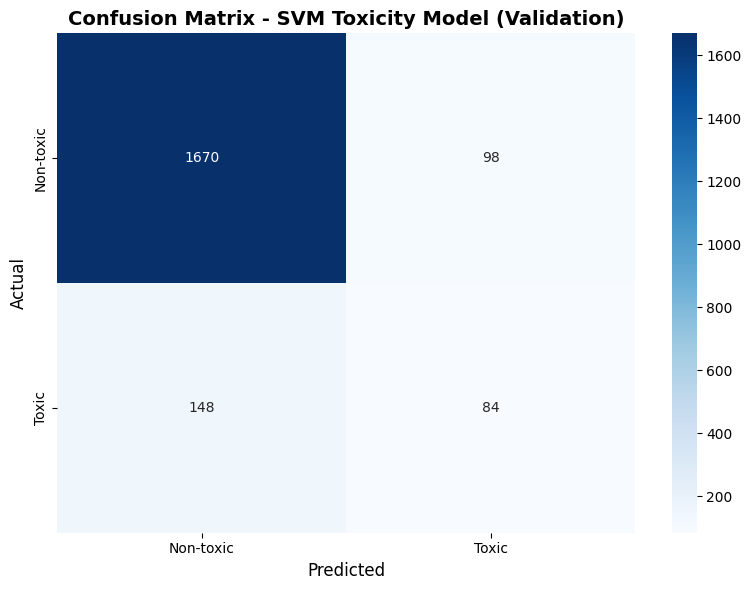


Confusion Matrix (SVM Toxicity - Validation):
[[1670   98]
 [ 148   84]]


In [12]:
# Evaluation on Validation Set - SVM Toxicity
y_pred_svm_toxic_val = best_svm_toxic.predict(X_valid_tfidf)
print("="*80)
print("TOXICITY CLASSIFICATION - SVM (VALIDATION SET)")
print("="*80)
print(classification_report(y_valid_toxic, y_pred_svm_toxic_val, target_names=['Non-toxic', 'Toxic']))
print(f"\nValidation Accuracy: {accuracy_score(y_valid_toxic, y_pred_svm_toxic_val):.4f}")
print(f"Validation F1 Score: {f1_score(y_valid_toxic, y_pred_svm_toxic_val, average='binary'):.4f}")

# Confusion Matrix for Validation Set
cm_svm_toxic_val = confusion_matrix(y_valid_toxic, y_pred_svm_toxic_val)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm_toxic_val, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Non-toxic', 'Toxic'],
            yticklabels=['Non-toxic', 'Toxic'])
plt.title('Confusion Matrix - SVM Toxicity Model (Validation)', fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.show()

print("\nConfusion Matrix (SVM Toxicity - Validation):")
print(cm_svm_toxic_val)

In [13]:
y_pred_svm_toxic = best_svm_toxic.predict(X_test_tfidf)
print("="*80)
print("TOXICITY CLASSIFICATION - SVM")
print("="*80)
print(classification_report(y_test_toxic, y_pred_svm_toxic, target_names=['Non-toxic', 'Toxic']))
print(f"\nTest Accuracy: {accuracy_score(y_test_toxic, y_pred_svm_toxic):.4f}")
print(f"Test F1 Score: {f1_score(y_test_toxic, y_pred_svm_toxic, average='binary'):.4f}")

with open('svm_toxicity_model.pkl', 'wb') as f:
    pickle.dump(best_svm_toxic, f)

TOXICITY CLASSIFICATION - SVM
              precision    recall  f1-score   support

   Non-toxic       0.93      0.94      0.93       890
       Toxic       0.46      0.40      0.43       110

    accuracy                           0.88      1000
   macro avg       0.69      0.67      0.68      1000
weighted avg       0.88      0.88      0.88      1000


Test Accuracy: 0.8820
Test F1 Score: 0.4272


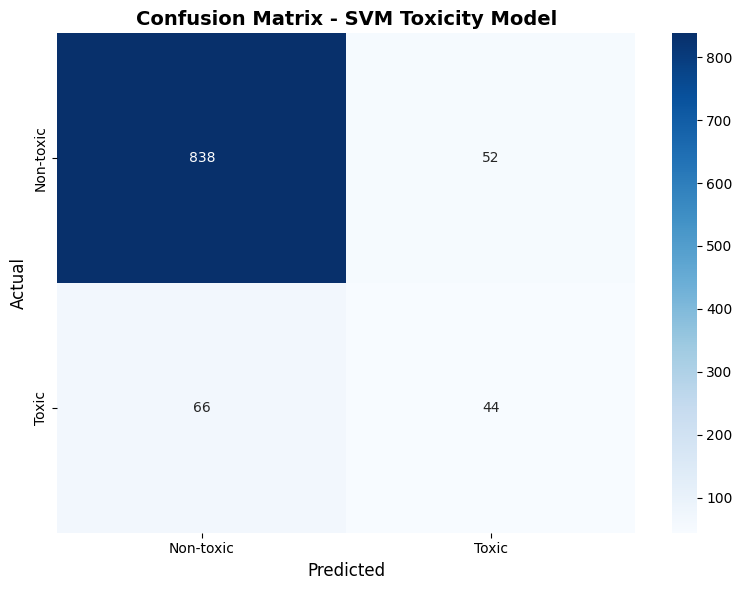


Confusion Matrix (SVM Toxicity):
[[838  52]
 [ 66  44]]


In [14]:
# Confusion Matrix for SVM Toxicity
cm_svm_toxic = confusion_matrix(y_test_toxic, y_pred_svm_toxic)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm_toxic, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Non-toxic', 'Toxic'],
            yticklabels=['Non-toxic', 'Toxic'])
plt.title('Confusion Matrix - SVM Toxicity Model', fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.show()

print("\nConfusion Matrix (SVM Toxicity):")
print(cm_svm_toxic)

### Phân tích Chi tiết - SVM Toxicity Model

In [15]:
# Phân tích mẫu DỰ ĐOÁN ĐÚNG - SVM Toxicity
print("="*80)
print("PHÂN TÍCH CÁC MẪU DỰ ĐOÁN ĐÚNG - SVM TOXICITY")
print("="*80)

y_pred_train_svm_toxic = best_svm_toxic.predict(X_train_tfidf)
correct_indices = np.where(y_pred_train_svm_toxic == y_train_toxic)[0]

# Lấy 2 mẫu dự đoán đúng cho mỗi class (0: Non-toxic, 1: Toxic)
samples_to_analyze = []
for class_id in [0, 1]:
    class_correct = correct_indices[y_train_toxic.iloc[correct_indices] == class_id]
    if len(class_correct) >= 2:
        samples_to_analyze.extend(class_correct[:2])

for sample_num, idx in enumerate(samples_to_analyze, 1):
    print(f"\n{'='*80}")
    print(f"Mẫu #{sample_num} - ĐÚNG")
    print(f"{'='*80}")
    print(f"Comment gốc: {train_df.iloc[idx]['Comment']}")
    print(f"Comment đã xử lý: {X_train.iloc[idx]}")
    
    actual = y_train_toxic.iloc[idx]
    predicted = y_pred_train_svm_toxic[idx]
    
    print(f"\nNhãn THỰC TẾ: {actual} ({'Toxic' if actual == 1 else 'Non-toxic'})")
    print(f"Nhãn DỰ ĐOÁN: {predicted} ({'Toxic' if predicted == 1 else 'Non-toxic'})")
    print(f"Kết quả: ✓ ĐÚNG\n")
    
    # Lấy vector TF-IDF
    tfidf_vector = X_train_tfidf[idx]
    feature_indices = tfidf_vector.nonzero()[1]
    tfidf_scores = tfidf_vector.toarray()[0][feature_indices]
    feature_names = np.array(tfidf.get_feature_names_out())[feature_indices]
    
    # Lấy trọng số SVM (binary classification: chỉ có 1 hàng coefficients)
    svm_weights = best_svm_toxic.coef_[0].toarray()[0][feature_indices]
    
    # Tính đóng góp
    contributions = tfidf_scores * svm_weights
    
    # Tạo DataFrame
    weight_df = pd.DataFrame({
        'Từ/ngram': feature_names,
        'TF-IDF': tfidf_scores,
        'Trọng số SVM (w)': svm_weights,
        'Đóng góp (TF-IDF × w)': contributions
    })
    
    # Sắp xếp theo giá trị đóng góp tuyệt đối
    weight_df = weight_df.reindex(weight_df['Đóng góp (TF-IDF × w)'].abs().sort_values(ascending=False).index)
    
    # Hiển thị tất cả features
    print(f"Tất cả {len(weight_df)} features (sắp xếp theo đóng góp tuyệt đối):\n")
    pd.options.display.float_format = '{:.6f}'.format
    print(weight_df.to_string(index=True))
    print("\n")

PHÂN TÍCH CÁC MẪU DỰ ĐOÁN ĐÚNG - SVM TOXICITY

Mẫu #1 - ĐÚNG
Comment gốc: Thật tuyệt vời...!!!
Comment đã xử lý: thật tuyệt_vời

Nhãn THỰC TẾ: 0 (Non-toxic)
Nhãn DỰ ĐOÁN: 0 (Non-toxic)
Kết quả: ✓ ĐÚNG

Tất cả 3 features (sắp xếp theo đóng góp tuyệt đối):

         Từ/ngram   TF-IDF  Trọng số SVM (w)  Đóng góp (TF-IDF × w)
2       tuyệt_vời 0.562612         -0.702259              -0.395099
0            thật 0.407336          0.534137               0.217573
1  thật tuyệt_vời 0.719407         -0.129024              -0.092820



Mẫu #2 - ĐÚNG
Comment gốc: mỹ đã tuột dốc quá nhiều rồi, giờ muốn vực dậy cũng rất khó
Comment đã xử lý: mỹ tuột dốc quá nhiều rồi giờ muốn vực dậy cũng rất khó

Nhãn THỰC TẾ: 0 (Non-toxic)
Nhãn DỰ ĐOÁN: 0 (Non-toxic)
Kết quả: ✓ ĐÚNG

Tất cả 25 features (sắp xếp theo đóng góp tuyệt đối):

     Từ/ngram   TF-IDF  Trọng số SVM (w)  Đóng góp (TF-IDF × w)
8         khó 0.136271         -0.631498              -0.086055
21       tuột 0.237229          0.299760           

In [16]:
# Phân tích mẫu DỰ ĐOÁN SAI - SVM Toxicity
print("="*80)
print("PHÂN TÍCH CÁC MẪU DỰ ĐOÁN SAI - SVM TOXICITY")
print("="*80)

incorrect_indices = np.where(y_pred_train_svm_toxic != y_train_toxic)[0]
print(f"\nTổng số dự đoán sai: {len(incorrect_indices)}")

# Lấy 2 mẫu dự đoán sai
samples_incorrect = incorrect_indices[:2] if len(incorrect_indices) >= 2 else incorrect_indices

for sample_num, idx in enumerate(samples_incorrect, 1):
    print(f"\n{'='*80}")
    print(f"Mẫu #{sample_num} - SAI")
    print(f"{'='*80}")
    print(f"Comment gốc: {train_df.iloc[idx]['Comment']}")
    print(f"Comment đã xử lý: {X_train.iloc[idx]}")
    
    actual = y_train_toxic.iloc[idx]
    predicted = y_pred_train_svm_toxic[idx]
    
    print(f"\nNhãn THỰC TẾ: {actual} ({'Toxic' if actual == 1 else 'Non-toxic'})")
    print(f"Nhãn DỰ ĐOÁN: {predicted} ({'Toxic' if predicted == 1 else 'Non-toxic'})")
    print(f"Kết quả: ✗ SAI\n")
    
    # Lấy vector TF-IDF
    tfidf_vector = X_train_tfidf[idx]
    feature_indices = tfidf_vector.nonzero()[1]
    tfidf_scores = tfidf_vector.toarray()[0][feature_indices]
    feature_names = np.array(tfidf.get_feature_names_out())[feature_indices]
    
    # Lấy trọng số SVM
    svm_weights = best_svm_toxic.coef_[0].toarray()[0][feature_indices]
    
    # Tính đóng góp
    contributions = tfidf_scores * svm_weights
    
    # Tạo DataFrame
    weight_df = pd.DataFrame({
        'Từ/ngram': feature_names,
        'TF-IDF': tfidf_scores,
        'Trọng số SVM (w)': svm_weights,
        'Đóng góp (TF-IDF × w)': contributions
    })
    
    # Sắp xếp theo giá trị đóng góp tuyệt đối
    weight_df = weight_df.reindex(weight_df['Đóng góp (TF-IDF × w)'].abs().sort_values(ascending=False).index)
    
    # Hiển thị tất cả features
    print(f"Tất cả {len(weight_df)} features (sắp xếp theo đóng góp tuyệt đối):\n")
    pd.options.display.float_format = '{:.6f}'.format
    print(weight_df.to_string(index=True))
    print("\n")

PHÂN TÍCH CÁC MẪU DỰ ĐOÁN SAI - SVM TOXICITY

Tổng số dự đoán sai: 1

Mẫu #1 - SAI
Comment gốc: Chỉ có 30 tháng tù với 2 mạng người
Comment đã xử lý: chỉ 30 tháng tù 2 mạng người

Nhãn THỰC TẾ: 0 (Non-toxic)
Nhãn DỰ ĐOÁN: 1 (Toxic)
Kết quả: ✗ SAI

Tất cả 11 features (sắp xếp theo đóng góp tuyệt đối):

      Từ/ngram   TF-IDF  Trọng số SVM (w)  Đóng góp (TF-IDF × w)
9           tù 0.292733          1.155329               0.338204
3       chỉ 30 0.366109         -0.866015              -0.317056
8     tháng tù 0.343246          0.885188               0.303837
0           30 0.272015          0.869515               0.236521
1     30 tháng 0.339756          0.640648               0.217664
10     tù mạng 0.412298         -0.515618              -0.212589
5   mạng người 0.343246          0.562824               0.193187
4         mạng 0.288020          0.358187               0.103165
6        người 0.135373          0.687925               0.093127
7        tháng 0.237419          0.263939      

## Model 2: SVM - Constructiveness Classification

In [17]:
def objective_svm_constructive(trial):
    C = trial.suggest_float('C', 0.1, 10.0)
    kernel = trial.suggest_categorical('kernel', ['linear', 'rbf'])
    gamma = trial.suggest_categorical('gamma', ['scale', 'auto']) if kernel == 'rbf' else 'scale'
    
    svm_model = SVC(C=C, kernel=kernel, gamma=gamma, class_weight='balanced', random_state=42, max_iter=1000)
    svm_model.fit(X_train_tfidf, y_train_constructive)
    
    y_pred = svm_model.predict(X_valid_tfidf)
    f1 = f1_score(y_valid_constructive, y_pred, average='binary')
    
    return f1

study_svm_constructive = optuna.create_study(
    direction='maximize', 
    study_name='svm_constructive_optimization',
    sampler=optuna.samplers.TPESampler(seed=SEED)
)
study_svm_constructive.optimize(objective_svm_constructive, n_trials=20, show_progress_bar=True)

print(f"\nBest SVM Constructiveness parameters: {study_svm_constructive.best_params}")
print(f"Best F1 score: {study_svm_constructive.best_value:.4f}")

[I 2026-01-07 19:35:45,485] A new study created in memory with name: svm_constructive_optimization


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-01-07 19:35:49,571] Trial 0 finished with value: 0.6526806526806527 and parameters: {'C': 3.807947176588889, 'kernel': 'linear'}. Best is trial 0 with value: 0.6526806526806527.
[I 2026-01-07 19:35:53,704] Trial 1 finished with value: 0.6526806526806527 and parameters: {'C': 6.026718993550662, 'kernel': 'linear'}. Best is trial 0 with value: 0.6526806526806527.
[I 2026-01-07 19:35:57,818] Trial 2 finished with value: 0.5342616342982778 and parameters: {'C': 0.6750277604651747, 'kernel': 'linear'}. Best is trial 0 with value: 0.6526806526806527.
[I 2026-01-07 19:36:01,985] Trial 3 finished with value: 0.6512455516014235 and parameters: {'C': 7.10991852018085, 'kernel': 'rbf', 'gamma': 'scale'}. Best is trial 0 with value: 0.6526806526806527.
[I 2026-01-07 19:36:06,154] Trial 4 finished with value: 0.6392479435957696 and parameters: {'C': 1.9000671753502962, 'kernel': 'rbf', 'gamma': 'scale'}. Best is trial 0 with value: 0.6526806526806527.
[I 2026-01-07 19:36:10,190] Trial 5 fin

In [18]:
# Visualize Optuna Study for SVM Constructiveness
fig1 = vis.plot_optimization_history(study_svm_constructive)
fig1.update_layout(title="Optimization History - SVM Constructiveness", width=900, height=500)
fig1.show()

fig2 = vis.plot_slice(study_svm_constructive)
fig2.update_layout(title="Parameter Relationships - SVM Constructiveness", width=900, height=600)
fig2.show()

In [19]:
best_svm_constructive = SVC(**study_svm_constructive.best_params, class_weight='balanced', random_state=42, max_iter=1000)
best_svm_constructive.fit(X_train_tfidf, y_train_constructive)

SVC(C=2.219208733592438, class_weight='balanced', kernel='linear',
    max_iter=1000, random_state=42)

CONSTRUCTIVENESS CLASSIFICATION - SVM (VALIDATION SET)
                  precision    recall  f1-score   support

Non-constructive       0.84      0.66      0.74      1271
    Constructive       0.57      0.78      0.66       729

        accuracy                           0.70      2000
       macro avg       0.70      0.72      0.70      2000
    weighted avg       0.74      0.70      0.71      2000


Validation Accuracy: 0.7040
Validation F1 Score: 0.6566


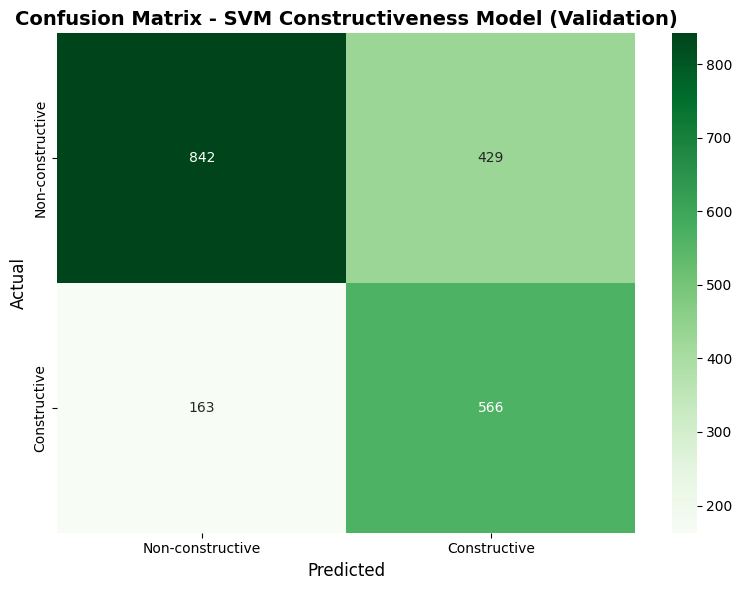


Confusion Matrix (SVM Constructiveness - Validation):
[[842 429]
 [163 566]]


In [20]:
# Evaluation on Validation Set - SVM Constructiveness
y_pred_svm_constructive_val = best_svm_constructive.predict(X_valid_tfidf)
print("="*80)
print("CONSTRUCTIVENESS CLASSIFICATION - SVM (VALIDATION SET)")
print("="*80)
print(classification_report(y_valid_constructive, y_pred_svm_constructive_val, target_names=['Non-constructive', 'Constructive']))
print(f"\nValidation Accuracy: {accuracy_score(y_valid_constructive, y_pred_svm_constructive_val):.4f}")
print(f"Validation F1 Score: {f1_score(y_valid_constructive, y_pred_svm_constructive_val, average='binary'):.4f}")

# Confusion Matrix for Validation Set
cm_svm_constructive_val = confusion_matrix(y_valid_constructive, y_pred_svm_constructive_val)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm_constructive_val, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Non-constructive', 'Constructive'],
            yticklabels=['Non-constructive', 'Constructive'])
plt.title('Confusion Matrix - SVM Constructiveness Model (Validation)', fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.show()

print("\nConfusion Matrix (SVM Constructiveness - Validation):")
print(cm_svm_constructive_val)

In [21]:
y_pred_svm_constructive = best_svm_constructive.predict(X_test_tfidf)
print("="*80)
print("CONSTRUCTIVENESS CLASSIFICATION - SVM")
print("="*80)
print(classification_report(y_test_constructive, y_pred_svm_constructive, target_names=['Non-constructive', 'Constructive']))
print(f"\nTest Accuracy: {accuracy_score(y_test_constructive, y_pred_svm_constructive):.4f}")
print(f"Test F1 Score: {f1_score(y_test_constructive, y_pred_svm_constructive, average='binary'):.4f}")

with open('svm_constructive_model.pkl', 'wb') as f:
    pickle.dump(best_svm_constructive, f)

CONSTRUCTIVENESS CLASSIFICATION - SVM
                  precision    recall  f1-score   support

Non-constructive       0.86      0.64      0.74       636
    Constructive       0.57      0.82      0.67       364

        accuracy                           0.71      1000
       macro avg       0.71      0.73      0.70      1000
    weighted avg       0.75      0.71      0.71      1000


Test Accuracy: 0.7070
Test F1 Score: 0.6697


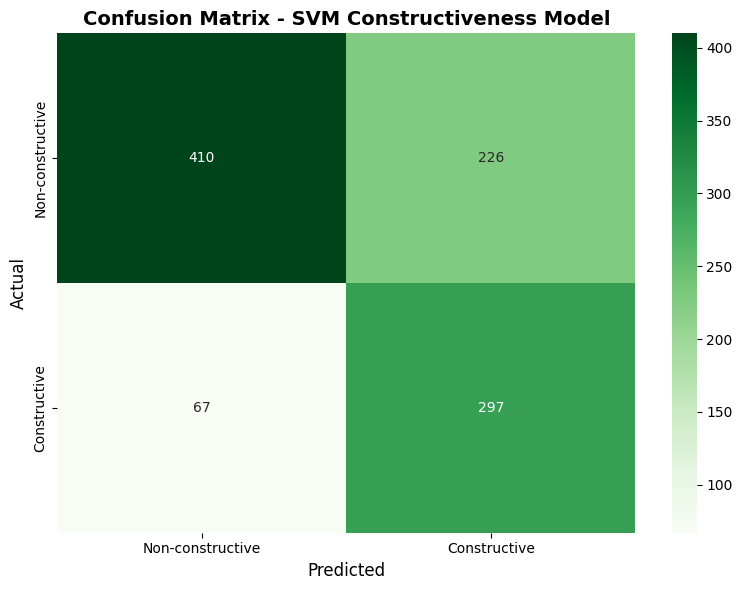


Confusion Matrix (SVM Constructiveness):
[[410 226]
 [ 67 297]]


In [22]:
# Confusion Matrix for SVM Constructiveness
cm_svm_constructive = confusion_matrix(y_test_constructive, y_pred_svm_constructive)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm_constructive, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Non-constructive', 'Constructive'],
            yticklabels=['Non-constructive', 'Constructive'])
plt.title('Confusion Matrix - SVM Constructiveness Model', fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.show()

print("\nConfusion Matrix (SVM Constructiveness):")
print(cm_svm_constructive)

### Phân tích Chi tiết - SVM Constructiveness Model

In [23]:
# Phân tích mẫu DỰ ĐOÁN ĐÚNG - SVM Constructiveness
print("="*80)
print("PHÂN TÍCH CÁC MẪU DỰ ĐOÁN ĐÚNG - SVM CONSTRUCTIVENESS")
print("="*80)

y_pred_train_svm_constructive = best_svm_constructive.predict(X_train_tfidf)
correct_indices = np.where(y_pred_train_svm_constructive == y_train_constructive)[0]

# Lấy 2 mẫu dự đoán đúng cho mỗi class
samples_to_analyze = []
for class_id in [0, 1]:
    class_correct = correct_indices[y_train_constructive.iloc[correct_indices] == class_id]
    if len(class_correct) >= 2:
        samples_to_analyze.extend(class_correct[:2])

for sample_num, idx in enumerate(samples_to_analyze, 1):
    print(f"\n{'='*80}")
    print(f"Mẫu #{sample_num} - ĐÚNG")
    print(f"{'='*80}")
    print(f"Comment gốc: {train_df.iloc[idx]['Comment']}")
    print(f"Comment đã xử lý: {X_train.iloc[idx]}")
    
    actual = y_train_constructive.iloc[idx]
    predicted = y_pred_train_svm_constructive[idx]
    
    print(f"\nNhãn THỰC TẾ: {actual} ({'Constructive' if actual == 1 else 'Non-constructive'})")
    print(f"Nhãn DỰ ĐOÁN: {predicted} ({'Constructive' if predicted == 1 else 'Non-constructive'})")
    print(f"Kết quả: ✓ ĐÚNG\n")
    
    # Lấy vector TF-IDF
    tfidf_vector = X_train_tfidf[idx]
    feature_indices = tfidf_vector.nonzero()[1]
    tfidf_scores = tfidf_vector.toarray()[0][feature_indices]
    feature_names = np.array(tfidf.get_feature_names_out())[feature_indices]
    
    # Lấy trọng số SVM
    svm_weights = best_svm_constructive.coef_[0].toarray()[0][feature_indices]
    
    # Tính đóng góp
    contributions = tfidf_scores * svm_weights
    
    # Tạo DataFrame
    weight_df = pd.DataFrame({
        'Từ/ngram': feature_names,
        'TF-IDF': tfidf_scores,
        'Trọng số SVM (w)': svm_weights,
        'Đóng góp (TF-IDF × w)': contributions
    })
    
    # Sắp xếp theo giá trị đóng góp tuyệt đối
    weight_df = weight_df.reindex(weight_df['Đóng góp (TF-IDF × w)'].abs().sort_values(ascending=False).index)
    
    # Hiển thị tất cả features
    print(f"Tất cả {len(weight_df)} features (sắp xếp theo đóng góp tuyệt đối):\n")
    pd.options.display.float_format = '{:.6f}'.format
    print(weight_df.to_string(index=True))
    print("\n")

PHÂN TÍCH CÁC MẪU DỰ ĐOÁN ĐÚNG - SVM CONSTRUCTIVENESS

Mẫu #1 - ĐÚNG
Comment gốc: Thật tuyệt vời...!!!
Comment đã xử lý: thật tuyệt_vời

Nhãn THỰC TẾ: 0 (Non-constructive)
Nhãn DỰ ĐOÁN: 0 (Non-constructive)
Kết quả: ✓ ĐÚNG

Tất cả 3 features (sắp xếp theo đóng góp tuyệt đối):

         Từ/ngram   TF-IDF  Trọng số SVM (w)  Đóng góp (TF-IDF × w)
1  thật tuyệt_vời 0.719407         -0.360011              -0.258994
0            thật 0.407336         -0.469063              -0.191066
2       tuyệt_vời 0.562612         -0.042547              -0.023937



Mẫu #2 - ĐÚNG
Comment gốc: Coi dịch là giặc. Đã mang tên đó mà xâm nhập VN thì phải đầu hàng hoặc cút xéo. VN luôn tự hào!
Comment đã xử lý: coi dịch giặc mang tên đó xâm_nhập vn phải đầu_hàng hoặc cút xéo vn luôn tự_hào

Nhãn THỰC TẾ: 0 (Non-constructive)
Nhãn DỰ ĐOÁN: 0 (Non-constructive)
Kết quả: ✓ ĐÚNG

Tất cả 30 features (sắp xếp theo đóng góp tuyệt đối):

         Từ/ngram   TF-IDF  Trọng số SVM (w)  Đóng góp (TF-IDF × w)
8            ho

In [24]:
# Phân tích mẫu DỰ ĐOÁN SAI - SVM Constructiveness
print("="*80)
print("PHÂN TÍCH CÁC MẪU DỰ ĐOÁN SAI - SVM CONSTRUCTIVENESS")
print("="*80)

incorrect_indices = np.where(y_pred_train_svm_constructive != y_train_constructive)[0]
print(f"\nTổng số dự đoán sai: {len(incorrect_indices)}")

# Lấy 2 mẫu dự đoán sai
samples_incorrect = incorrect_indices[:2] if len(incorrect_indices) >= 2 else incorrect_indices

for sample_num, idx in enumerate(samples_incorrect, 1):
    print(f"\n{'='*80}")
    print(f"Mẫu #{sample_num} - SAI")
    print(f"{'='*80}")
    print(f"Comment gốc: {train_df.iloc[idx]['Comment']}")
    print(f"Comment đã xử lý: {X_train.iloc[idx]}")
    
    actual = y_train_constructive.iloc[idx]
    predicted = y_pred_train_svm_constructive[idx]
    
    print(f"\nNhãn THỰC TẾ: {actual} ({'Constructive' if actual == 1 else 'Non-constructive'})")
    print(f"Nhãn DỰ ĐOÁN: {predicted} ({'Constructive' if predicted == 1 else 'Non-constructive'})")
    print(f"Kết quả: ✗ SAI\n")
    
    # Lấy vector TF-IDF
    tfidf_vector = X_train_tfidf[idx]
    feature_indices = tfidf_vector.nonzero()[1]
    tfidf_scores = tfidf_vector.toarray()[0][feature_indices]
    feature_names = np.array(tfidf.get_feature_names_out())[feature_indices]
    
    # Lấy trọng số SVM
    svm_weights = best_svm_constructive.coef_[0].toarray()[0][feature_indices]
    
    # Tính đóng góp
    contributions = tfidf_scores * svm_weights
    
    # Tạo DataFrame
    weight_df = pd.DataFrame({
        'Từ/ngram': feature_names,
        'TF-IDF': tfidf_scores,
        'Trọng số SVM (w)': svm_weights,
        'Đóng góp (TF-IDF × w)': contributions
    })
    
    # Sắp xếp theo giá trị đóng góp tuyệt đối
    weight_df = weight_df.reindex(weight_df['Đóng góp (TF-IDF × w)'].abs().sort_values(ascending=False).index)
    
    # Hiển thị tất cả features
    print(f"Tất cả {len(weight_df)} features (sắp xếp theo đóng góp tuyệt đối):\n")
    pd.options.display.float_format = '{:.6f}'.format
    print(weight_df.to_string(index=True))
    print("\n")

PHÂN TÍCH CÁC MẪU DỰ ĐOÁN SAI - SVM CONSTRUCTIVENESS

Tổng số dự đoán sai: 408

Mẫu #1 - SAI
Comment gốc: Phản ánh một thực tế khoảng cách giàu nghèo ngày càng lớn. Vẫn còn nhiều đứa trẻ không biết bánh trung thu là gì. Chạnh lòng.
Comment đã xử lý: phản_ánh một thực_tế khoảng_cách giàu nghèo ngày_càng lớn vẫn còn nhiều đứa trẻ không biết bánh_trung_thu gì chạnh_lòng

Nhãn THỰC TẾ: 0 (Non-constructive)
Nhãn DỰ ĐOÁN: 1 (Constructive)
Kết quả: ✗ SAI

Tất cả 35 features (sắp xếp theo đóng góp tuyệt đối):

               Từ/ngram   TF-IDF  Trọng số SVM (w)  Đóng góp (TF-IDF × w)
21            ngày_càng 0.154601          0.500432               0.077367
32              vẫn còn 0.144129          0.473811               0.068290
27              thực_tế 0.141618          0.426286               0.060370
29                  trẻ 0.113452          0.486210               0.055162
6             còn nhiều 0.164680          0.251339               0.041390
19                nghèo 0.158139         -0.2505

## Model 3: Logistic Regression - Toxicity Classification

In [25]:
def objective_lr_toxicity(trial):
    C = trial.suggest_float('C', 0.01, 10.0)
    solver = trial.suggest_categorical('solver', ['lbfgs', 'saga'])
    penalty = trial.suggest_categorical('penalty', ['l2'])
    
    lr_model = LogisticRegression(C=C, solver=solver, penalty=penalty, 
                                   class_weight='balanced', random_state=42, max_iter=1000)
    lr_model.fit(X_train_tfidf, y_train_toxic)
    
    y_pred = lr_model.predict(X_valid_tfidf)
    f1 = f1_score(y_valid_toxic, y_pred, average='binary')
    
    return f1

study_lr_toxic = optuna.create_study(
    direction='maximize', 
    study_name='lr_toxicity_optimization',
    sampler=optuna.samplers.TPESampler(seed=SEED)
)
study_lr_toxic.optimize(objective_lr_toxicity, n_trials=20, show_progress_bar=True)

print(f"\nBest Logistic Regression Toxicity parameters: {study_lr_toxic.best_params}")
print(f"Best F1 score: {study_lr_toxic.best_value:.4f}")

[I 2026-01-07 19:37:15,980] A new study created in memory with name: lr_toxicity_optimization


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-01-07 19:37:17,137] Trial 0 finished with value: 0.4557522123893805 and parameters: {'C': 3.7516557872851513, 'solver': 'lbfgs', 'penalty': 'l2'}. Best is trial 0 with value: 0.4557522123893805.
[I 2026-01-07 19:37:18,050] Trial 1 finished with value: 0.4439359267734554 and parameters: {'C': 5.990598257128395, 'solver': 'lbfgs', 'penalty': 'l2'}. Best is trial 0 with value: 0.4557522123893805.
[I 2026-01-07 19:37:18,952] Trial 2 finished with value: 0.4620811287477954 and parameters: {'C': 0.5902552855603126, 'solver': 'lbfgs', 'penalty': 'l2'}. Best is trial 2 with value: 0.4620811287477954.
[I 2026-01-07 19:37:19,491] Trial 3 finished with value: 0.4428904428904429 and parameters: {'C': 7.0836450521824945, 'solver': 'saga', 'penalty': 'l2'}. Best is trial 2 with value: 0.4620811287477954.
[I 2026-01-07 19:37:20,745] Trial 4 finished with value: 0.44285714285714284 and parameters: {'C': 8.326101981596214, 'solver': 'lbfgs', 'penalty': 'l2'}. Best is trial 2 with value: 0.46208

In [26]:
# Visualize Optuna Study for Logistic Regression Toxicity
fig1 = vis.plot_optimization_history(study_lr_toxic)
fig1.update_layout(title="Optimization History - Logistic Regression Toxicity", width=900, height=500)
fig1.show()

fig2 = vis.plot_slice(study_lr_toxic)
fig2.update_layout(title="Parameter Relationships - Logistic Regression Toxicity", width=900, height=600)
fig2.show()

In [27]:
best_lr_toxic = LogisticRegression(**study_lr_toxic.best_params, class_weight='balanced', 
                             random_state=42, max_iter=1000)
best_lr_toxic.fit(X_train_tfidf, y_train_toxic)

LogisticRegression(C=2.0841122277989577, class_weight='balanced', max_iter=1000,
                   random_state=42, solver='saga')

TOXICITY CLASSIFICATION - Logistic Regression (VALIDATION SET)
              precision    recall  f1-score   support

   Non-toxic       0.93      0.93      0.93      1768
       Toxic       0.47      0.50      0.48       232

    accuracy                           0.88      2000
   macro avg       0.70      0.71      0.71      2000
weighted avg       0.88      0.88      0.88      2000


Validation Accuracy: 0.8760
Validation F1 Score: 0.4812


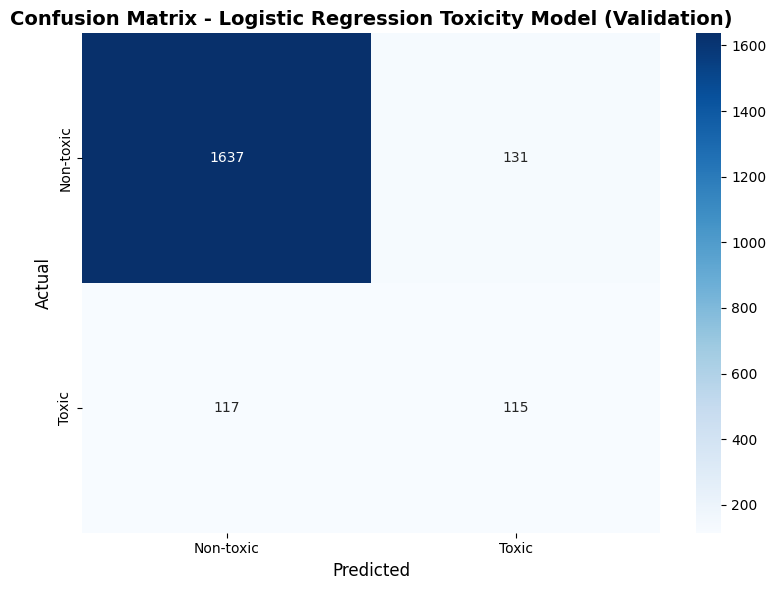


Confusion Matrix (LR Toxicity - Validation):
[[1637  131]
 [ 117  115]]


In [28]:
# Evaluation on Validation Set - Logistic Regression Toxicity
y_pred_lr_toxic_val = best_lr_toxic.predict(X_valid_tfidf)
print("="*80)
print("TOXICITY CLASSIFICATION - Logistic Regression (VALIDATION SET)")
print("="*80)
print(classification_report(y_valid_toxic, y_pred_lr_toxic_val, target_names=['Non-toxic', 'Toxic']))
print(f"\nValidation Accuracy: {accuracy_score(y_valid_toxic, y_pred_lr_toxic_val):.4f}")
print(f"Validation F1 Score: {f1_score(y_valid_toxic, y_pred_lr_toxic_val, average='binary'):.4f}")

# Confusion Matrix for Validation Set
cm_lr_toxic_val = confusion_matrix(y_valid_toxic, y_pred_lr_toxic_val)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr_toxic_val, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Non-toxic', 'Toxic'],
            yticklabels=['Non-toxic', 'Toxic'])
plt.title('Confusion Matrix - Logistic Regression Toxicity Model (Validation)', fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.show()

print("\nConfusion Matrix (LR Toxicity - Validation):")
print(cm_lr_toxic_val)

In [29]:
y_pred_lr_toxic = best_lr_toxic.predict(X_test_tfidf)
print("="*80)
print("TOXICITY CLASSIFICATION - Logistic Regression")
print("="*80)
print(classification_report(y_test_toxic, y_pred_lr_toxic, target_names=['Non-toxic', 'Toxic']))
print(f"\nTest Accuracy: {accuracy_score(y_test_toxic, y_pred_lr_toxic):.4f}")
print(f"Test F1 Score: {f1_score(y_test_toxic, y_pred_lr_toxic, average='binary'):.4f}")

with open('lr_toxicity_model.pkl', 'wb') as f:
    pickle.dump(best_lr_toxic, f)

TOXICITY CLASSIFICATION - Logistic Regression
              precision    recall  f1-score   support

   Non-toxic       0.94      0.92      0.93       890
       Toxic       0.45      0.51      0.48       110

    accuracy                           0.88      1000
   macro avg       0.69      0.72      0.70      1000
weighted avg       0.88      0.88      0.88      1000


Test Accuracy: 0.8780
Test F1 Score: 0.4786


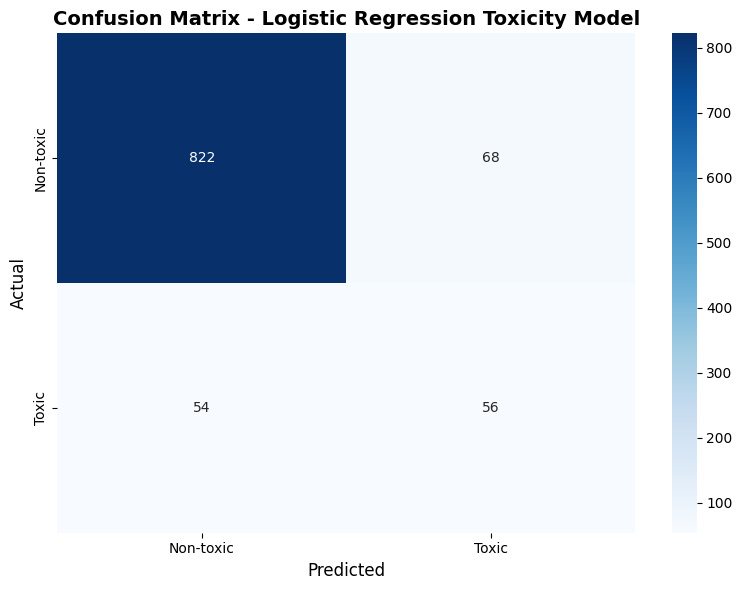


Confusion Matrix (LR Toxicity):
[[822  68]
 [ 54  56]]


In [30]:
# Confusion Matrix for LR Toxicity
cm_lr_toxic = confusion_matrix(y_test_toxic, y_pred_lr_toxic)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr_toxic, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Non-toxic', 'Toxic'],
            yticklabels=['Non-toxic', 'Toxic'])
plt.title('Confusion Matrix - Logistic Regression Toxicity Model', fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.show()

print("\nConfusion Matrix (LR Toxicity):")
print(cm_lr_toxic)

## Model 4: Logistic Regression - Constructiveness Classification

In [31]:
def objective_lr_constructive(trial):
    C = trial.suggest_float('C', 0.01, 10.0)
    solver = trial.suggest_categorical('solver', ['lbfgs', 'saga'])
    penalty = trial.suggest_categorical('penalty', ['l2'])
    
    lr_model = LogisticRegression(C=C, solver=solver, penalty=penalty, 
                                   class_weight='balanced', random_state=42, max_iter=1000)
    lr_model.fit(X_train_tfidf, y_train_constructive)
    
    y_pred = lr_model.predict(X_valid_tfidf)
    f1 = f1_score(y_valid_constructive, y_pred, average='binary')
    
    return f1

study_lr_constructive = optuna.create_study(
    direction='maximize', 
    study_name='lr_constructive_optimization',
    sampler=optuna.samplers.TPESampler(seed=SEED)
)
study_lr_constructive.optimize(objective_lr_constructive, n_trials=20, show_progress_bar=True)

print(f"\nBest Logistic Regression Constructiveness parameters: {study_lr_constructive.best_params}")
print(f"Best F1 score: {study_lr_constructive.best_value:.4f}")

[I 2026-01-07 19:38:22,285] A new study created in memory with name: lr_constructive_optimization


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-01-07 19:38:24,974] Trial 0 finished with value: 0.6967213114754098 and parameters: {'C': 3.7516557872851513, 'solver': 'lbfgs', 'penalty': 'l2'}. Best is trial 0 with value: 0.6967213114754098.
[I 2026-01-07 19:38:26,806] Trial 1 finished with value: 0.6995884773662552 and parameters: {'C': 5.990598257128395, 'solver': 'lbfgs', 'penalty': 'l2'}. Best is trial 1 with value: 0.6995884773662552.
[I 2026-01-07 19:38:28,147] Trial 2 finished with value: 0.6824858757062147 and parameters: {'C': 0.5902552855603126, 'solver': 'lbfgs', 'penalty': 'l2'}. Best is trial 1 with value: 0.6995884773662552.
[I 2026-01-07 19:38:28,615] Trial 3 finished with value: 0.6985250737463127 and parameters: {'C': 7.0836450521824945, 'solver': 'saga', 'penalty': 'l2'}. Best is trial 1 with value: 0.6995884773662552.
[I 2026-01-07 19:38:31,268] Trial 4 finished with value: 0.6997635933806147 and parameters: {'C': 8.326101981596214, 'solver': 'lbfgs', 'penalty': 'l2'}. Best is trial 4 with value: 0.699763

In [32]:
# Visualize Optuna Study for Logistic Regression Constructiveness
fig1 = vis.plot_optimization_history(study_lr_constructive)
fig1.update_layout(title="Optimization History - Logistic Regression Constructiveness", width=900, height=500)
fig1.show()

fig2 = vis.plot_slice(study_lr_constructive)
fig2.update_layout(title="Parameter Relationships - Logistic Regression Constructiveness", width=900, height=600)
fig2.show()

In [33]:
best_lr_constructive = LogisticRegression(**study_lr_constructive.best_params, class_weight='balanced', 
                             random_state=42, max_iter=1000)
best_lr_constructive.fit(X_train_tfidf, y_train_constructive)

LogisticRegression(C=9.69567573677078, class_weight='balanced', max_iter=1000,
                   random_state=42)

CONSTRUCTIVENESS CLASSIFICATION - Logistic Regression (VALIDATION SET)
                  precision    recall  f1-score   support

Non-constructive       0.87      0.71      0.78      1271
    Constructive       0.62      0.81      0.70       729

        accuracy                           0.75      2000
       macro avg       0.74      0.76      0.74      2000
    weighted avg       0.78      0.75      0.75      2000


Validation Accuracy: 0.7480
Validation F1 Score: 0.7014


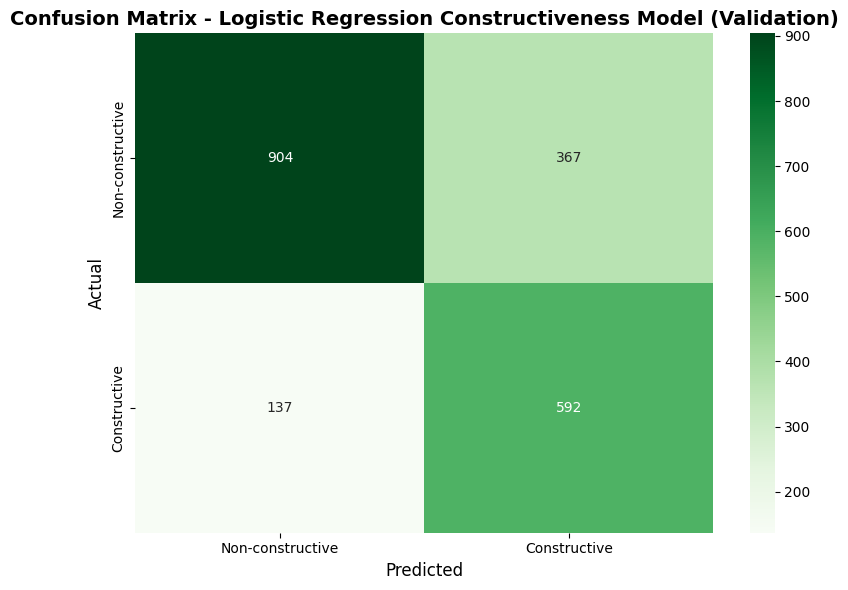


Confusion Matrix (LR Constructiveness - Validation):
[[904 367]
 [137 592]]


In [34]:
# Evaluation on Validation Set - Logistic Regression Constructiveness
y_pred_lr_constructive_val = best_lr_constructive.predict(X_valid_tfidf)
print("="*80)
print("CONSTRUCTIVENESS CLASSIFICATION - Logistic Regression (VALIDATION SET)")
print("="*80)
print(classification_report(y_valid_constructive, y_pred_lr_constructive_val, target_names=['Non-constructive', 'Constructive']))
print(f"\nValidation Accuracy: {accuracy_score(y_valid_constructive, y_pred_lr_constructive_val):.4f}")
print(f"Validation F1 Score: {f1_score(y_valid_constructive, y_pred_lr_constructive_val, average='binary'):.4f}")

# Confusion Matrix for Validation Set
cm_lr_constructive_val = confusion_matrix(y_valid_constructive, y_pred_lr_constructive_val)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr_constructive_val, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Non-constructive', 'Constructive'],
            yticklabels=['Non-constructive', 'Constructive'])
plt.title('Confusion Matrix - Logistic Regression Constructiveness Model (Validation)', fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.show()

print("\nConfusion Matrix (LR Constructiveness - Validation):")
print(cm_lr_constructive_val)

In [35]:
y_pred_lr_constructive = best_lr_constructive.predict(X_test_tfidf)
print("="*80)
print("CONSTRUCTIVENESS CLASSIFICATION - Logistic Regression")
print("="*80)
print(classification_report(y_test_constructive, y_pred_lr_constructive, target_names=['Non-constructive', 'Constructive']))
print(f"\nTest Accuracy: {accuracy_score(y_test_constructive, y_pred_lr_constructive):.4f}")
print(f"Test F1 Score: {f1_score(y_test_constructive, y_pred_lr_constructive, average='binary'):.4f}")

with open('lr_constructive_model.pkl', 'wb') as f:
    pickle.dump(best_lr_constructive, f)

CONSTRUCTIVENESS CLASSIFICATION - Logistic Regression
                  precision    recall  f1-score   support

Non-constructive       0.91      0.71      0.80       636
    Constructive       0.64      0.88      0.74       364

        accuracy                           0.77      1000
       macro avg       0.77      0.80      0.77      1000
    weighted avg       0.81      0.77      0.78      1000


Test Accuracy: 0.7730
Test F1 Score: 0.7382


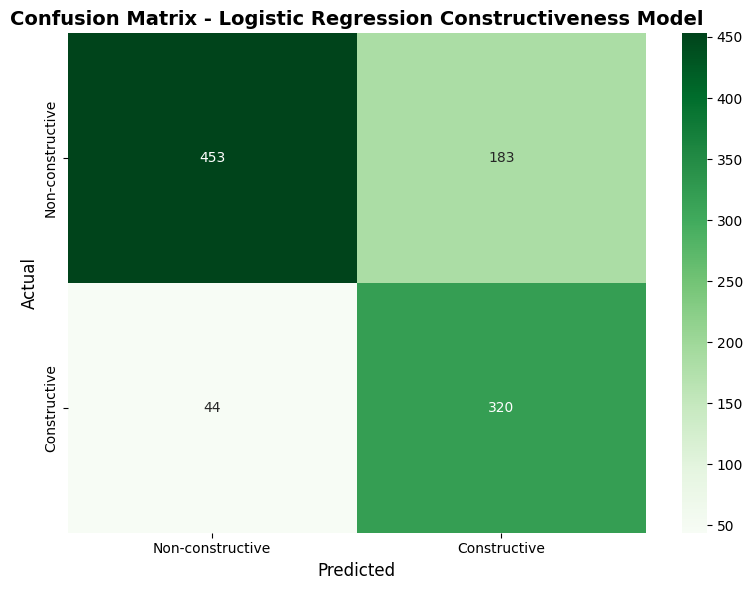


Confusion Matrix (LR Constructiveness):
[[453 183]
 [ 44 320]]


In [36]:
# Confusion Matrix for LR Constructiveness
cm_lr_constructive = confusion_matrix(y_test_constructive, y_pred_lr_constructive)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr_constructive, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Non-constructive', 'Constructive'],
            yticklabels=['Non-constructive', 'Constructive'])
plt.title('Confusion Matrix - Logistic Regression Constructiveness Model', fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.show()

print("\nConfusion Matrix (LR Constructiveness):")
print(cm_lr_constructive)

## Model 5: LSTM - Toxicity Classification

In [37]:
MAX_WORDS = 10000
MAX_LEN = 100

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_valid_seq = tokenizer.texts_to_sequences(X_valid)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_valid_pad = pad_sequences(X_valid_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post', truncating='post')

print(f"Training sequences shape: {X_train_pad.shape}")
print(f"Validation sequences shape: {X_valid_pad.shape}")
print(f"Test sequences shape: {X_test_pad.shape}")

Training sequences shape: (7000, 100)
Validation sequences shape: (2000, 100)
Test sequences shape: (1000, 100)


In [38]:
def create_lstm_model_toxicity(embedding_dim, lstm_units, dropout_rate, learning_rate):
    model = Sequential([
        Embedding(MAX_WORDS, embedding_dim, input_length=MAX_LEN),
        Bidirectional(LSTM(lstm_units, return_sequences=False)),
        Dropout(dropout_rate),
        Dense(64, activation='relu'),
        Dropout(dropout_rate),
        Dense(1, activation='sigmoid')  # Binary classification
    ])
    
    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, 
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    
    return model

def objective_lstm_toxicity(trial):
    embedding_dim = trial.suggest_categorical('embedding_dim', [64, 128, 256])
    lstm_units = trial.suggest_categorical('lstm_units', [64, 128, 256])
    dropout_rate = trial.suggest_float('dropout_rate', 0.2, 0.5)
    learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical('batch_size', [32, 64])
    # Set seeds for this trial
    tf.random.set_seed(SEED)
    np.random.seed(SEED)
    
    model = create_lstm_model_toxicity(embedding_dim, lstm_units, dropout_rate, learning_rate)
    
    # Tính class weights cho imbalanced data
    class_weights = compute_class_weight('balanced', classes=np.unique(y_train_toxic), y=y_train_toxic)
    class_weight_dict = dict(enumerate(class_weights))
    
    early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
    
    history = model.fit(
        X_train_pad, y_train_toxic,
        validation_data=(X_valid_pad, y_valid_toxic),
        epochs=10,
        batch_size=batch_size,
        class_weight=class_weight_dict,
        callbacks=[early_stop],
        verbose=0
    )
    
    y_pred = model.predict(X_valid_pad, verbose=0)
    y_pred_classes = (y_pred > 0.5).astype(int).flatten()
    f1 = f1_score(y_valid_toxic, y_pred_classes, average='binary')
    
    return f1

study_lstm_toxic = optuna.create_study(
    direction='maximize', 
    study_name='lstm_toxicity_optimization',
    sampler=optuna.samplers.TPESampler(seed=SEED)
)
study_lstm_toxic.optimize(objective_lstm_toxicity, n_trials=20, show_progress_bar=True)

print(f"\nBest LSTM Toxicity parameters: {study_lstm_toxic.best_params}")
print(f"Best F1 score: {study_lstm_toxic.best_value:.4f}")

[I 2026-01-07 19:38:57,704] A new study created in memory with name: lstm_toxicity_optimization


  0%|          | 0/20 [00:00<?, ?it/s]

I0000 00:00:1767814738.011265      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1767814738.015147      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
2026-01-07 19:38:58.184260: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be 

[I 2026-01-07 19:39:13,086] Trial 0 finished with value: 0.4120603015075377 and parameters: {'embedding_dim': 128, 'lstm_units': 64, 'dropout_rate': 0.21742508365045984, 'learning_rate': 0.005399484409787433, 'batch_size': 64}. Best is trial 0 with value: 0.4120603015075377.


2026-01-07 19:39:18.551542: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
2026-01-07 19:39:31.582431: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

...

[I 2026-01-07 19:45:57,479] Trial 17 finished with value: 0.4371584699453552 and parameters: {'embedding_dim': 64, 'lstm_units': 128, 'dropout_rate': 0.3233109428683644, 'learning_rate': 0.0004670191263144113, 'batch_size': 32}. Best is trial 3 with value: 0.4448462929475588.


2026-01-07 19:46:02.429929: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
2026-01-07 19:46:17.724623: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

[I 2026-01-07 19:46:18,393] Trial 18 finished with value: 0.40933572710951527 and parameters: {'embedding_dim': 256, 'lstm_units': 128, 'dropout_rate': 0.32456198490898996, 'learning_rate': 0.00021434460789703514, 'batch_size': 64}. Best is trial 3 with value: 0.4448462929475588.


2026-01-07 19:46:24.032420: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
2026-01-07 19:46:37.498411: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

[I 2026-01-07 19:46:38,133] Trial 19 finished with value: 0.41203703703703703 and parameters: {'embedding_dim': 128, 'lstm_units': 128, 'dropout_rate': 0.26679070419832634, 'learning_rate': 0.0026681180583773305, 'batch_size': 32}. Best is trial 3 with value: 0.4448462929475588.

Best LSTM Toxicity parameters: {'embedding_dim': 64, 'lstm_units': 128, 'dropout_rate': 0.2913841307520112, 'learning_rate': 0.0001567993391672301, 'batch_size': 32}
Best F1 score: 0.4448


In [39]:
# Visualize Optuna Study for LSTM Toxicity
fig1 = vis.plot_optimization_history(study_lstm_toxic)
fig1.update_layout(title="Optimization History - LSTM Toxicity", width=900, height=500)
fig1.show()

fig2 = vis.plot_slice(study_lstm_toxic)
fig2.update_layout(title="Parameter Relationships - LSTM Toxicity", width=900, height=600)
fig2.show()

In [40]:
best_params_toxic = study_lstm_toxic.best_params
best_lstm_toxic = create_lstm_model_toxicity(
    best_params_toxic['embedding_dim'],
    best_params_toxic['lstm_units'],
    best_params_toxic['dropout_rate'],
    best_params_toxic['learning_rate']
)

# Tính class weights cho imbalanced data
class_weights = compute_class_weight('balanced', classes=np.unique(y_train_toxic), y=y_train_toxic)
class_weight_dict = dict(enumerate(class_weights))

early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = best_lstm_toxic.fit(
    X_train_pad, y_train_toxic,
    validation_data=(X_valid_pad, y_valid_toxic),
    epochs=20,
    batch_size=best_params_toxic['batch_size'],
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5360 - loss: 0.6990

2026-01-07 19:46:43.816103: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


219/219 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.5361 - loss: 0.6990 - val_accuracy: 0.1570 - val_loss: 0.7152
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.6232 - loss: 0.6533 - val_accuracy: 0.8190 - val_loss: 0.4329
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.8098 - loss: 0.4417 - val_accuracy: 0.8745 - val_loss: 0.3580
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.8478 - loss: 0.3525 - val_accuracy: 0.8690 - val_loss: 0.3994
Epoch 5/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.8904 - loss: 0.2665 - val_accuracy: 0.8280 - val_loss: 0.4494
Epoch 6/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9177 - loss: 0.1964 - val_accuracy: 0.8575 - val_loss: 0.7395
Epoch 7/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.8245 - loss: 0.8969 - val_accuracy: 0.8210 - val_loss: 0.5043
Epoch 8/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9262 - loss: 0.1700 - val_accuracy: 0.834

2026-01-07 19:47:06.815203: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


TOXICITY CLASSIFICATION - LSTM (VALIDATION SET)
              precision    recall  f1-score   support

   Non-toxic       0.92      0.94      0.93      1768
       Toxic       0.45      0.40      0.42       232

    accuracy                           0.87      2000
   macro avg       0.69      0.67      0.68      2000
weighted avg       0.87      0.87      0.87      2000


Validation Accuracy: 0.8745
Validation F1 Score: 0.4230


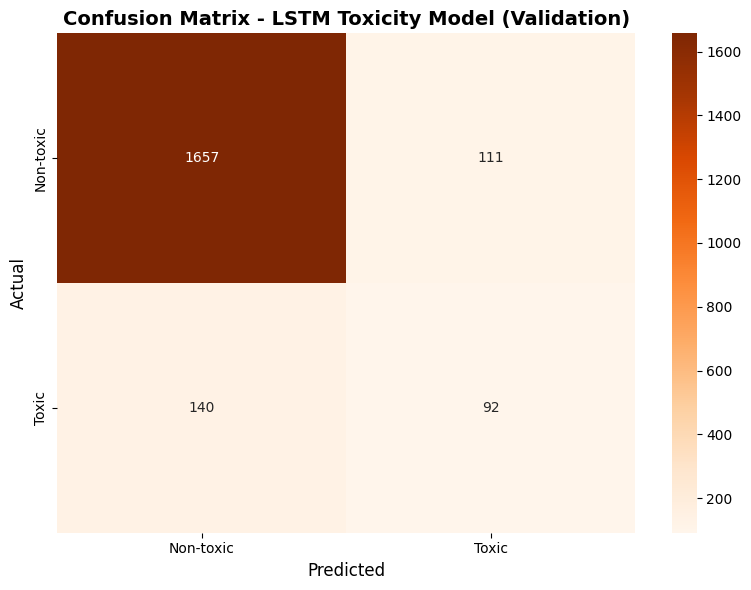


Confusion Matrix (LSTM Toxicity - Validation):
[[1657  111]
 [ 140   92]]


In [41]:
# Evaluation on Validation Set - LSTM Toxicity
y_pred_lstm_toxic_val = best_lstm_toxic.predict(X_valid_pad, verbose=0)
y_pred_lstm_toxic_val_classes = (y_pred_lstm_toxic_val > 0.5).astype(int).flatten()

print("="*80)
print("TOXICITY CLASSIFICATION - LSTM (VALIDATION SET)")
print("="*80)
print(classification_report(y_valid_toxic, y_pred_lstm_toxic_val_classes, target_names=['Non-toxic', 'Toxic']))
print(f"\nValidation Accuracy: {accuracy_score(y_valid_toxic, y_pred_lstm_toxic_val_classes):.4f}")
print(f"Validation F1 Score: {f1_score(y_valid_toxic, y_pred_lstm_toxic_val_classes, average='binary'):.4f}")

# Confusion Matrix for Validation Set
cm_lstm_toxic_val = confusion_matrix(y_valid_toxic, y_pred_lstm_toxic_val_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_lstm_toxic_val, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['Non-toxic', 'Toxic'],
            yticklabels=['Non-toxic', 'Toxic'])
plt.title('Confusion Matrix - LSTM Toxicity Model (Validation)', fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.show()

print("\nConfusion Matrix (LSTM Toxicity - Validation):")
print(cm_lstm_toxic_val)

In [42]:
y_pred_lstm_toxic = best_lstm_toxic.predict(X_test_pad, verbose=0)
y_pred_lstm_toxic_classes = (y_pred_lstm_toxic > 0.5).astype(int).flatten()

print("="*80)
print("TOXICITY CLASSIFICATION - LSTM")
print("="*80)
print(classification_report(y_test_toxic, y_pred_lstm_toxic_classes, target_names=['Non-toxic', 'Toxic']))
print(f"\nTest Accuracy: {accuracy_score(y_test_toxic, y_pred_lstm_toxic_classes):.4f}")
print(f"Test F1 Score: {f1_score(y_test_toxic, y_pred_lstm_toxic_classes, average='binary'):.4f}")

best_lstm_toxic.save('lstm_toxicity_model.keras')

TOXICITY CLASSIFICATION - LSTM
              precision    recall  f1-score   support

   Non-toxic       0.93      0.94      0.94       890
       Toxic       0.49      0.44      0.46       110

    accuracy                           0.89      1000
   macro avg       0.71      0.69      0.70      1000
weighted avg       0.88      0.89      0.89      1000


Test Accuracy: 0.8890
Test F1 Score: 0.4638


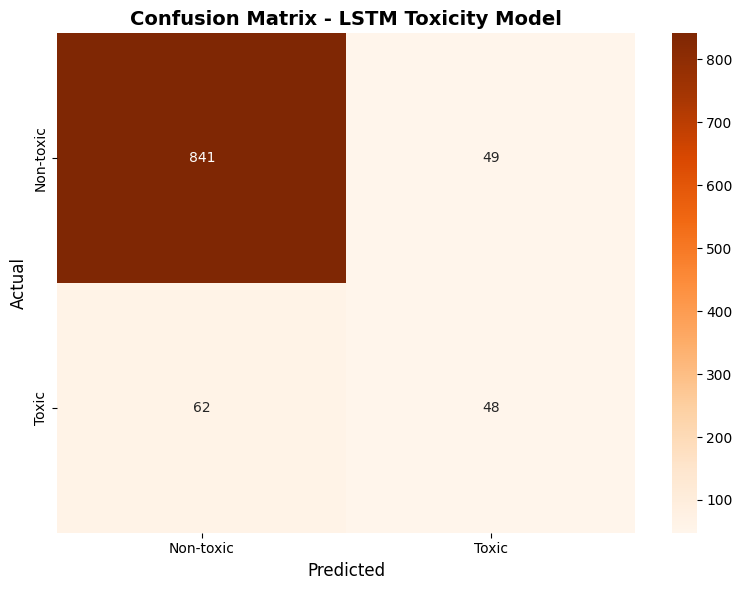


Confusion Matrix (LSTM Toxicity):
[[841  49]
 [ 62  48]]


In [43]:
# Confusion Matrix for LSTM Toxicity
cm_lstm_toxic = confusion_matrix(y_test_toxic, y_pred_lstm_toxic_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_lstm_toxic, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['Non-toxic', 'Toxic'],
            yticklabels=['Non-toxic', 'Toxic'])
plt.title('Confusion Matrix - LSTM Toxicity Model', fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.show()

print("\nConfusion Matrix (LSTM Toxicity):")
print(cm_lstm_toxic)

## Model 6: LSTM - Constructiveness Classification

In [44]:
def create_lstm_model_constructive(embedding_dim, lstm_units, dropout_rate, learning_rate):
    model = Sequential([
        Embedding(MAX_WORDS, embedding_dim, input_length=MAX_LEN),
        Bidirectional(LSTM(lstm_units, return_sequences=False)),
        Dropout(dropout_rate),
        Dense(64, activation='relu'),
        Dropout(dropout_rate),
        Dense(1, activation='sigmoid')  # Binary classification
    ])
    
    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, 
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    
    return model

def objective_lstm_constructive(trial):
    embedding_dim = trial.suggest_categorical('embedding_dim', [64, 128, 256])
    lstm_units = trial.suggest_categorical('lstm_units', [64, 128, 256])
    dropout_rate = trial.suggest_float('dropout_rate', 0.2, 0.5)
    learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical('batch_size', [32, 64])
    
    tf.random.set_seed(SEED)
    np.random.seed(SEED)
    
    model = create_lstm_model_constructive(embedding_dim, lstm_units, dropout_rate, learning_rate)
    
    # Tính class weights cho imbalanced data
    class_weights = compute_class_weight('balanced', classes=np.unique(y_train_constructive), y=y_train_constructive)
    class_weight_dict = dict(enumerate(class_weights))
    
    early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
    
    history = model.fit(
        X_train_pad, y_train_constructive,
        validation_data=(X_valid_pad, y_valid_constructive),
        epochs=10,
        batch_size=batch_size,
        class_weight=class_weight_dict,
        callbacks=[early_stop],
        verbose=0
    )
    
    y_pred = model.predict(X_valid_pad, verbose=0)
    y_pred_classes = (y_pred > 0.5).astype(int).flatten()
    f1 = f1_score(y_valid_constructive, y_pred_classes, average='binary')
    
    return f1

study_lstm_constructive = optuna.create_study(
    direction='maximize', 
    study_name='lstm_constructive_optimization',
    sampler=optuna.samplers.TPESampler(seed=SEED)
)
study_lstm_constructive.optimize(objective_lstm_constructive, n_trials=20, show_progress_bar=True)

print(f"\nBest LSTM Constructiveness parameters: {study_lstm_constructive.best_params}")
print(f"Best F1 score: {study_lstm_constructive.best_value:.4f}")

[I 2026-01-07 19:47:08,444] A new study created in memory with name: lstm_constructive_optimization


  0%|          | 0/20 [00:00<?, ?it/s]

2026-01-07 19:47:12.942022: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
2026-01-07 19:47:19.240787: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

[I 2026-01-07 19:47:19,896] Trial 0 finished with value: 0.7431077694235589 and parameters: {'embedding_dim': 128, 'lstm_units': 64, 'dropout_rate': 0.21742508365045984, 'learning_rate': 0.005399484409787433, 'batch_size': 64}. Best is trial 0 with value: 0.7431077694235589.


2026-01-07 19:47:25.419071: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
2026-01-07 19:47:35.419575: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

...

[I 2026-01-07 19:51:52,772] Trial 17 finished with value: 0.7366283006093433 and parameters: {'embedding_dim': 256, 'lstm_units': 128, 'dropout_rate': 0.4011996315543955, 'learning_rate': 0.0018004220442378474, 'batch_size': 64}. Best is trial 14 with value: 0.749034749034749.


2026-01-07 19:51:57.518799: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
2026-01-07 19:52:04.546819: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

[I 2026-01-07 19:52:05,199] Trial 18 finished with value: 0.7338308457711443 and parameters: {'embedding_dim': 128, 'lstm_units': 128, 'dropout_rate': 0.32456198490898996, 'learning_rate': 0.0005887566238745413, 'batch_size': 64}. Best is trial 14 with value: 0.749034749034749.


2026-01-07 19:52:10.844196: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
2026-01-07 19:52:20.751692: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

[I 2026-01-07 19:52:21,507] Trial 19 finished with value: 0.7327586206896551 and parameters: {'embedding_dim': 128, 'lstm_units': 256, 'dropout_rate': 0.3944188793383421, 'learning_rate': 0.005874380174127434, 'batch_size': 64}. Best is trial 14 with value: 0.749034749034749.

Best LSTM Constructiveness parameters: {'embedding_dim': 128, 'lstm_units': 128, 'dropout_rate': 0.40741767772530557, 'learning_rate': 0.008218484458650201, 'batch_size': 64}
Best F1 score: 0.7490


In [45]:
# Visualize Optuna Study for LSTM Constructiveness
fig1 = vis.plot_optimization_history(study_lstm_constructive)
fig1.update_layout(title="Optimization History - LSTM Constructiveness", width=900, height=500)
fig1.show()

fig2 = vis.plot_slice(study_lstm_constructive)
fig2.update_layout(title="Parameter Relationships - LSTM Constructiveness", width=900, height=600)
fig2.show()

In [46]:
best_params_constructive = study_lstm_constructive.best_params
best_lstm_constructive = create_lstm_model_constructive(
    best_params_constructive['embedding_dim'],
    best_params_constructive['lstm_units'],
    best_params_constructive['dropout_rate'],
    best_params_constructive['learning_rate']
)

# Tính class weights cho imbalanced data
class_weights = compute_class_weight('balanced', classes=np.unique(y_train_constructive), y=y_train_constructive)
class_weight_dict = dict(enumerate(class_weights))

early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = best_lstm_constructive.fit(
    X_train_pad, y_train_constructive,
    validation_data=(X_valid_pad, y_valid_constructive),
    epochs=20,
    batch_size=best_params_constructive['batch_size'],
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
109/110 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7051 - loss: 0.5872

2026-01-07 19:52:26.469475: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.7061 - loss: 0.5857 - val_accuracy: 0.8010 - val_loss: 0.4407
Epoch 2/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.8178 - loss: 0.3963 - val_accuracy: 0.8090 - val_loss: 0.4768
Epoch 3/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.8701 - loss: 0.3200 - val_accuracy: 0.7700 - val_loss: 0.5815
Epoch 4/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9114 - loss: 0.2268 - val_accuracy: 0.7810 - val_loss: 0.5719
Epoch 5/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9195 - loss: 0.1882 - val_accuracy: 0.7680 - val_loss: 0.8330
Epoch 6/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9433 - loss: 0.1547 - val_accuracy: 0.7655 - val_loss: 0.9783


2026-01-07 19:52:38.215970: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


CONSTRUCTIVENESS CLASSIFICATION - LSTM (VALIDATION SET)
                  precision    recall  f1-score   support

Non-constructive       0.88      0.80      0.84      1271
    Constructive       0.69      0.81      0.75       729

        accuracy                           0.80      2000
       macro avg       0.79      0.80      0.79      2000
    weighted avg       0.81      0.80      0.80      2000


Validation Accuracy: 0.8010
Validation F1 Score: 0.7481


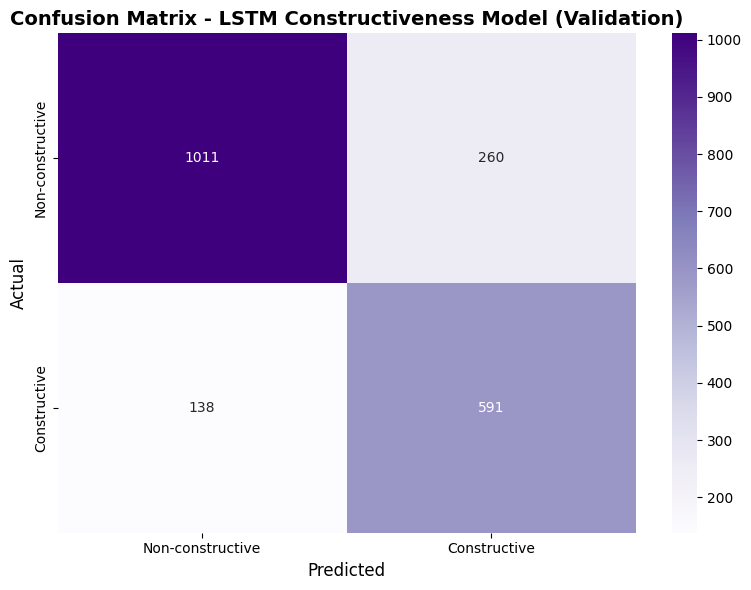


Confusion Matrix (LSTM Constructiveness - Validation):
[[1011  260]
 [ 138  591]]


In [47]:
# Evaluation on Validation Set - LSTM Constructiveness
y_pred_lstm_constructive_val = best_lstm_constructive.predict(X_valid_pad, verbose=0)
y_pred_lstm_constructive_val_classes = (y_pred_lstm_constructive_val > 0.5).astype(int).flatten()

print("="*80)
print("CONSTRUCTIVENESS CLASSIFICATION - LSTM (VALIDATION SET)")
print("="*80)
print(classification_report(y_valid_constructive, y_pred_lstm_constructive_val_classes, target_names=['Non-constructive', 'Constructive']))
print(f"\nValidation Accuracy: {accuracy_score(y_valid_constructive, y_pred_lstm_constructive_val_classes):.4f}")
print(f"Validation F1 Score: {f1_score(y_valid_constructive, y_pred_lstm_constructive_val_classes, average='binary'):.4f}")

# Confusion Matrix for Validation Set
cm_lstm_constructive_val = confusion_matrix(y_valid_constructive, y_pred_lstm_constructive_val_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_lstm_constructive_val, annot=True, fmt='d', cmap='Purples', 
            xticklabels=['Non-constructive', 'Constructive'],
            yticklabels=['Non-constructive', 'Constructive'])
plt.title('Confusion Matrix - LSTM Constructiveness Model (Validation)', fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.show()

print("\nConfusion Matrix (LSTM Constructiveness - Validation):")
print(cm_lstm_constructive_val)

In [48]:
y_pred_lstm_constructive = best_lstm_constructive.predict(X_test_pad, verbose=0)
y_pred_lstm_constructive_classes = (y_pred_lstm_constructive > 0.5).astype(int).flatten()

print("="*80)
print("CONSTRUCTIVENESS CLASSIFICATION - LSTM")
print("="*80)
print(classification_report(y_test_constructive, y_pred_lstm_constructive_classes, target_names=['Non-constructive', 'Constructive']))
print(f"\nTest Accuracy: {accuracy_score(y_test_constructive, y_pred_lstm_constructive_classes):.4f}")
print(f"Test F1 Score: {f1_score(y_test_constructive, y_pred_lstm_constructive_classes, average='binary'):.4f}")

best_lstm_constructive.save('lstm_constructive_model.keras')
with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

CONSTRUCTIVENESS CLASSIFICATION - LSTM
                  precision    recall  f1-score   support

Non-constructive       0.90      0.78      0.83       636
    Constructive       0.69      0.84      0.76       364

        accuracy                           0.80      1000
       macro avg       0.79      0.81      0.80      1000
    weighted avg       0.82      0.80      0.81      1000


Test Accuracy: 0.8030
Test F1 Score: 0.7571


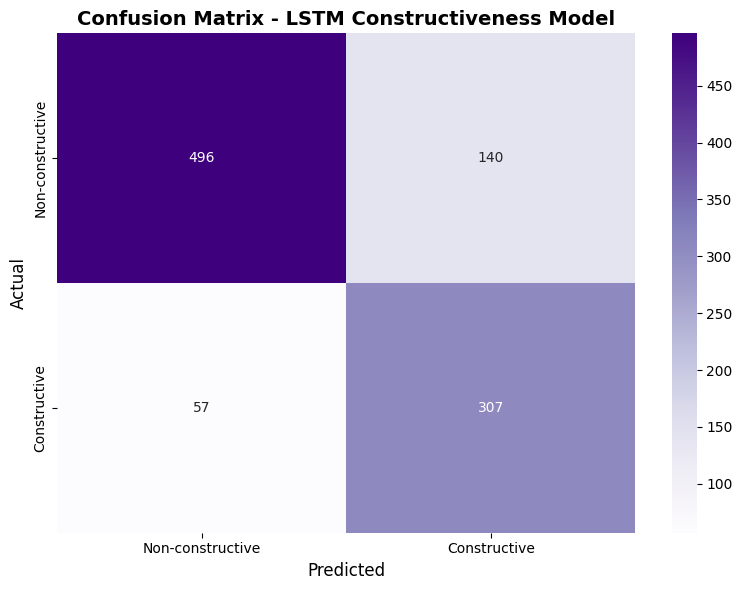


Confusion Matrix (LSTM Constructiveness):
[[496 140]
 [ 57 307]]


In [49]:
# Confusion Matrix for LSTM Constructiveness
cm_lstm_constructive = confusion_matrix(y_test_constructive, y_pred_lstm_constructive_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_lstm_constructive, annot=True, fmt='d', cmap='Purples', 
            xticklabels=['Non-constructive', 'Constructive'],
            yticklabels=['Non-constructive', 'Constructive'])
plt.title('Confusion Matrix - LSTM Constructiveness Model', fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.show()

print("\nConfusion Matrix (LSTM Constructiveness):")
print(cm_lstm_constructive)

## Gradio Demo - Test All Models (Separate Toxicity & Constructiveness Predictions)

In [7]:
# Load tất cả models
# SVM Models
with open('svm_toxicity_model.pkl', 'rb') as f:
    loaded_svm_toxic = pickle.load(f)
    
with open('svm_constructive_model.pkl', 'rb') as f:
    loaded_svm_constructive = pickle.load(f)

# Logistic Regression Models
with open('lr_toxicity_model.pkl', 'rb') as f:
    loaded_lr_toxic = pickle.load(f)
    
with open('lr_constructive_model.pkl', 'rb') as f:
    loaded_lr_constructive = pickle.load(f)

# LSTM Models
loaded_lstm_toxic = keras.models.load_model('lstm_toxicity_model.keras')
loaded_lstm_constructive = keras.models.load_model('lstm_constructive_model.keras')

# TF-IDF and Tokenizer
with open('tfidf_vectorizer.pkl', 'rb') as f:
    loaded_tfidf = pickle.load(f)
    
with open('tokenizer.pkl', 'rb') as f:
    loaded_tokenizer = pickle.load(f)

In [10]:
def predict_comment(text, model_choice):
    """Predict toxicity and constructiveness of a comment separately"""
    
    if not text.strip():
        return "Please enter a comment to analyze."
    
    processed_text = preprocess_text(text)
    
    # Dự đoán Toxicity và Constructiveness riêng biệt
    if model_choice == "SVM":
        text_tfidf = loaded_tfidf.transform([processed_text])
        
        # Toxicity prediction
        toxic_pred = loaded_svm_toxic.predict(text_tfidf)[0]
        toxic_proba = loaded_svm_toxic.decision_function(text_tfidf)[0]
        
        # Constructiveness prediction
        constructive_pred = loaded_svm_constructive.predict(text_tfidf)[0]
        constructive_proba = loaded_svm_constructive.decision_function(text_tfidf)[0]
        
        # Normalize probabilities
        toxic_prob_norm = 1 / (1 + np.exp(-toxic_proba))
        constructive_prob_norm = 1 / (1 + np.exp(-constructive_proba))
        
    elif model_choice == "Logistic Regression":
        text_tfidf = loaded_tfidf.transform([processed_text])
        
        # Toxicity prediction
        toxic_pred = loaded_lr_toxic.predict(text_tfidf)[0]
        toxic_proba = loaded_lr_toxic.predict_proba(text_tfidf)[0]
        
        # Constructiveness prediction
        constructive_pred = loaded_lr_constructive.predict(text_tfidf)[0]
        constructive_proba = loaded_lr_constructive.predict_proba(text_tfidf)[0]
        
        toxic_prob_norm = toxic_proba[1]  # Probability of toxic
        constructive_prob_norm = constructive_proba[1]  # Probability of constructive
        
    elif model_choice == "LSTM":
        text_seq = loaded_tokenizer.texts_to_sequences([processed_text])
        text_pad = pad_sequences(text_seq, maxlen=MAX_LEN, padding='post', truncating='post')
        
        # Toxicity prediction
        toxic_proba = loaded_lstm_toxic.predict(text_pad, verbose=0)[0][0]
        toxic_pred = 1 if toxic_proba > 0.5 else 0
        
        # Constructiveness prediction
        constructive_proba = loaded_lstm_constructive.predict(text_pad, verbose=0)[0][0]
        constructive_pred = 1 if constructive_proba > 0.5 else 0
        
        toxic_prob_norm = toxic_proba
        constructive_prob_norm = constructive_proba
    
    # Format results
    result = f"Model: {model_choice}\n\n"
    result += "TOXICITY PREDICTION\n"
    result += f"Prediction: {'✗ TOXIC' if toxic_pred == 1 else '✓ Non-toxic'}\n"
    result += f"Confidence: {toxic_prob_norm:.2%}\n\n"
    
    result += "CONSTRUCTIVENESS PREDICTION\n"
    result += f"Prediction: {'✓ Constructive' if constructive_pred == 1 else '✗ Non-constructive'}\n"
    result += f"Confidence: {constructive_prob_norm:.2%}\n\n"
    
    result += "SUMMARY\n"
    
    # Determine overall classification
    if toxic_pred == 0 and constructive_pred == 0:
        overall = "🔵 Non-toxic & Non-constructive"
    elif toxic_pred == 0 and constructive_pred == 1:
        overall = "🟢 Non-toxic & Constructive"
    elif toxic_pred == 1 and constructive_pred == 0:
        overall = "🔴 Toxic & Non-constructive"
    else:  # toxic_pred == 1 and constructive_pred == 1
        overall = "🟡 Toxic & Constructive"
    
    result += f"**Overall:** {overall}\n"
    
    return result

demo = gr.Interface(
    fn=predict_comment,
    inputs=[
        gr.Textbox(
            lines=5, 
            placeholder="Nhập comment tiếng Việt của bạn...",
            label="Vietnamese Comment"
        ),
        gr.Radio(
            choices=["SVM", "Logistic Regression", "LSTM"],
            value="SVM",
            label="Select Model"
        )
    ],
    outputs=gr.Textbox(label="Prediction Results", lines=15),
    title="🔍 Vietnamese Comment Toxicity & Constructiveness Classifier",
    description="Enter a Vietnamese comment to classify its toxicity and constructiveness separately using SVM, Logistic Regression, or LSTM models.",
    examples=[
        ["Người ta đã định bán gấp xe Hàn rồi mà cắm đầu vô mấy cái congnong minin này làm gì, cùng đời săn được em Altis hoặc Vios nào đi còn sướng chán chứ dại gì chơi mấy cái máy cày congnong này. Thân !", "SVM"],
        ["khổ cho cháu bé quá vì đã gặp người bố tàn ác quá", "Logistic Regression"],
        ["Electra thiết kế tối giản nhưng vô cùng đẹp đẽ và mạnh mẽ.Thay cho nhà Toy, Alphard thiết kế cho người ngoài hành tinh", "LSTM"],
    ],
    theme=gr.themes.Soft()
)

demo.launch(share=True)

* Running on local URL:  http://127.0.0.1:7861

Could not create share link. Please check your internet connection or our status page: https://status.gradio.app.
